# 02 — Markov Engine

Demonstrates the 3-state Markov regime model:

1. **Regime classification** — adaptive threshold = 0.5 × median(|returns|)
2. **Transition matrix** — Dirichlet smoothing + exponential decay
3. **Structural break detection** — Frobenius norm of first/second half matrices
4. **Forecast** — matrix exponentiation Pⁿ
5. **Momentum signal** — velocity, acceleration, trend strength (R²)
6. **Regime up-rates** — empirical P(up | regime) from historical data

**Prerequisites:**
```bash
conda activate cramer-research
cd ../research && pip install -e . && cd ../notebooks
```

In [1]:
import os
import sys

sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from research.data.prices import fetch_historical_prices
from research.models.markov import (
    classify_regime_series,
    estimate_transition_matrix,
    detect_structural_break,
    compute_markov_forecast,
)
from research.viz.distributions import plot_regime_sequence

## 1. Load Historical Prices

In [2]:
TICKER = "BTC"
DAYS = 180
HORIZON = 7

prices = fetch_historical_prices(TICKER, days=DAYS)
prices['returns'] = prices['close'].pct_change()
returns = prices['returns'].dropna().values
current_price = float(prices['close'].iloc[-1])

print(f"Source: {prices.attrs.get('source', 'unknown')}")
print(f"Current price: ${current_price:,.2f}")
print(f"Returns: {len(returns)} days, mean={returns.mean():.4f}, std={returns.std():.4f}")

Source: binance
Current price: $77,613.65
Returns: 179 days, mean=-0.0015, std=0.0263


## 2. Regime Classification

Adaptive threshold = 0.5 × median(|returns|) ensures ~30-40% bull, ~30-40% bear regardless of volatility.

In [3]:
regimes = classify_regime_series(returns)

# Counts
from collections import Counter
counts = Counter(regimes)
for state in ['bull', 'bear', 'sideways']:
    print(f"{state:8s}: {counts[state]:4d} days ({100*counts[state]/len(regimes):.1f}%)")

print(f"\nAdaptive threshold: {0.5 * np.median(np.abs(returns)):.4f}")

bull    :   58 days (32.4%)
bear    :   69 days (38.5%)
sideways:   52 days (29.1%)

Adaptive threshold: 0.0069


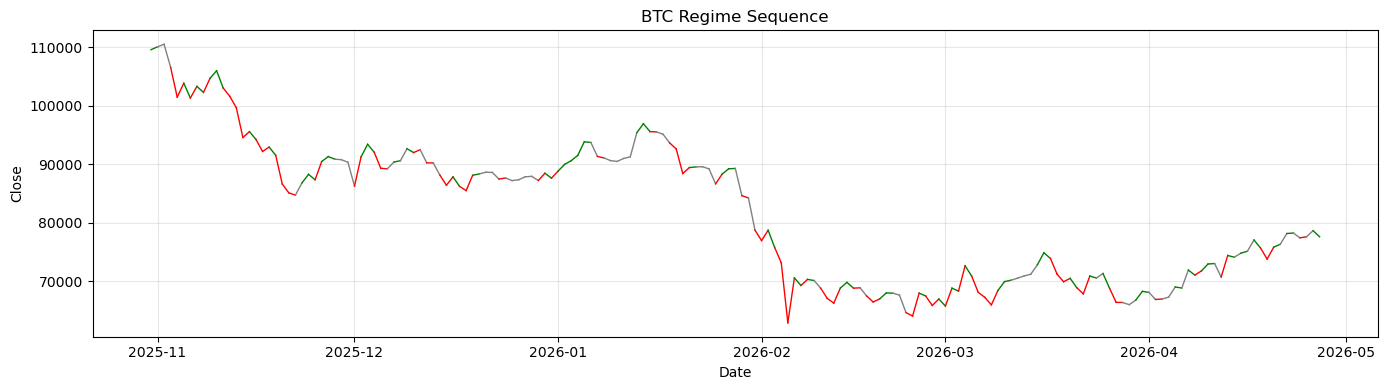

In [4]:
fig = plot_regime_sequence(prices.iloc[1:], regimes, title=f"{TICKER} Regime Sequence")
plt.tight_layout()
plt.show()

## 3. Transition Matrix

Estimate with Dirichlet smoothing (`α = max(0.01, 5/N)`) and exponential decay (`decay_rate=0.97`).

Recent transitions get higher weight: `weight = decay_rate^(distance_from_end)`.

In [5]:
DECAY_RATE = 0.97
P = estimate_transition_matrix(regimes, decay_rate=DECAY_RATE)

states = ['bull', 'bear', 'sideways']
P_df = pd.DataFrame(P, index=states, columns=states)
print("Transition Matrix P:")
print(P_df.round(4))

# Verify rows sum to 1
print("\nRow sums:", P_df.sum(axis=1).values)

Transition Matrix P:
            bull    bear  sideways
bull      0.1691  0.3646    0.4663
bear      0.4212  0.3688    0.2100
sideways  0.5171  0.2633    0.2196

Row sums: [1. 1. 1.]


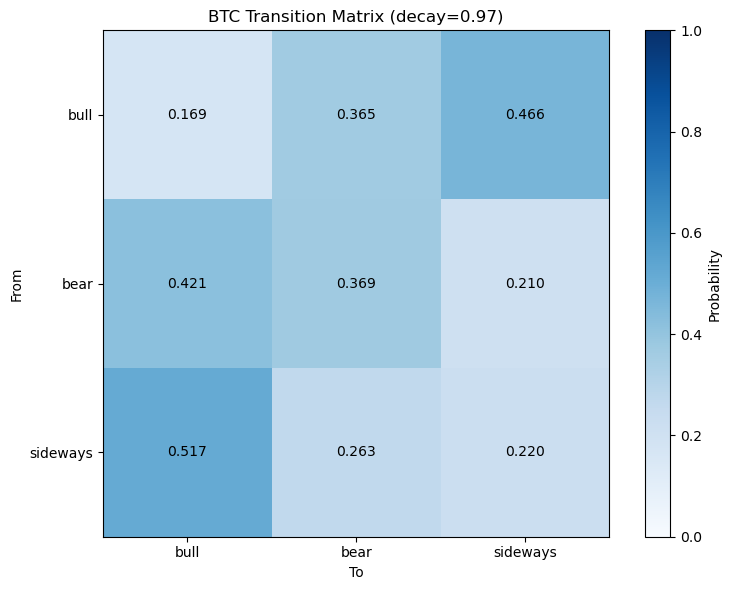

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(P, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(states)
ax.set_yticklabels(states)
ax.set_xlabel('To')
ax.set_ylabel('From')
ax.set_title(f'{TICKER} Transition Matrix (decay={DECAY_RATE})')

# Annotate cells
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{P[i,j]:.3f}', ha='center', va='center', color='black')

plt.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()
plt.show()

## 4. Structural Break Detection

Split the regime sequence in half and compare transition matrices via Frobenius divergence.
If divergence > threshold (default 0.05), the market regime has shifted.

In [7]:
break_result = detect_structural_break(regimes, divergence_threshold=0.05, decay_rate=DECAY_RATE)

print(f"Structural break detected: {break_result['detected']}")
print(f"Divergence: {break_result['divergence']:.6f}")
print("\nFirst half matrix:")
print(pd.DataFrame(break_result['first_half_matrix'], index=states, columns=states).round(4))
print("\nSecond half matrix:")
print(pd.DataFrame(break_result['second_half_matrix'], index=states, columns=states).round(4))

Structural break detected: True
Divergence: 0.523021

First half matrix:
            bull    bear  sideways
bull      0.4709  0.2832    0.2459
bear      0.4199  0.3225    0.2575
sideways  0.1033  0.3006    0.5961

Second half matrix:
            bull    bear  sideways
bull      0.1584  0.3700    0.4716
bear      0.4192  0.3710    0.2099
sideways  0.5470  0.2618    0.1912


## 5. Forecast via Matrix Exponentiation

Compute regime probabilities at horizon = `HORIZON` days using Pⁿ.

`P(up) = Σ P(regime_i at horizon) × P(up | regime_i)`

In [8]:
current_regime = regimes[-1]
forecast = compute_markov_forecast(P, current_regime, HORIZON)

print(f"Current regime: {current_regime}")
print(f"Forecast at horizon={HORIZON} days:")
for state, prob in forecast.items():
    print(f"  P({state:8s}): {prob:.4f}")

Current regime: bear
Forecast at horizon=7 days:
  P(bull    ): 0.3598
  P(bear    ): 0.3351
  P(sideways): 0.3051


## 6. Regime Up-Rates (Empirical)

For each day in regime R, look forward `horizon` days and check if cumulative return was positive.
This gives the actual frequency of 'up' outcomes per regime.

In [9]:
def compute_regime_up_rates(regimes, returns, horizon, decay_rate=0.97):
    counts = {s: {'up': 0.0, 'total': 0.0} for s in ['bull', 'bear', 'sideways']}
    max_start = min(len(regimes), len(returns)) - horizon
    
    for i in range(max_start):
        regime = regimes[i]
        cum_return = sum(returns[i+1:i+1+horizon])
        weight = decay_rate ** (max_start - 1 - i)
        counts[regime]['total'] += weight
        if cum_return > 0:
            counts[regime]['up'] += weight
    
    return {
        s: counts[s]['up'] / counts[s]['total'] if counts[s]['total'] > 0 else 0.5
        for s in ['bull', 'bear', 'sideways']
    }

up_rates = compute_regime_up_rates(regimes, returns, HORIZON, DECAY_RATE)
print(f"Empirical P(up | regime) over {HORIZON} days:")
for state, rate in up_rates.items():
    print(f"  {state:8s}: {rate:.4f}")

Empirical P(up | regime) over 7 days:
  bull    : 0.6974
  bear    : 0.6789
  sideways: 0.7117


In [10]:
# Combined forecast: regime probabilities × up-rates
combined_p_up = sum(forecast[s] * up_rates[s] for s in ['bull', 'bear', 'sideways'])
print(f"Combined P(up) at horizon={HORIZON}: {combined_p_up:.4f}")
print(f"Directional signal: {'BULLISH' if combined_p_up > 0.5 else 'BEARISH'}")

Combined P(up) at horizon=7: 0.6956
Directional signal: BULLISH


## 7. Momentum Signal

Compute velocity, acceleration, and trend strength (R² of OLS on log-prices).
The adjustment is a small daily drift tilt = velocity/252 × trendStrength × 0.25, clamped to ±0.003.

In [11]:
def compute_momentum_signal(prices_arr, lookback=20):
    if len(prices_arr) < lookback + 1:
        return {'velocity': 0, 'acceleration': 0, 'trend_strength': 0, 'adjustment': 0}
    
    window = prices_arr[-lookback-1:]
    total_return = window[-1] / window[0] - 1
    velocity = np.sign(total_return) * ((1 + abs(total_return)) ** (252 / lookback) - 1)
    
    half = lookback // 2
    recent_ret = window[-1] / window[-1-half] - 1
    older_ret = window[-1-half] / window[0] - 1
    recent_vel = np.sign(recent_ret) * ((1 + abs(recent_ret)) ** (252 / half) - 1)
    older_vel = np.sign(older_ret) * ((1 + abs(older_ret)) ** (252 / half) - 1)
    acceleration = recent_vel - older_vel
    
    # Trend strength: R² of OLS on log(prices)
    log_prices = np.log(window)
    n = len(log_prices)
    x_mean = (n - 1) / 2
    y_mean = log_prices.mean()
    sxy = sum((i - x_mean) * (lp - y_mean) for i, lp in enumerate(log_prices))
    sxx = sum((i - x_mean) ** 2 for i in range(n))
    syy = sum((lp - y_mean) ** 2 for lp in log_prices)
    trend_strength = (sxy * sxy) / (sxx * syy) if syy > 0 else 0
    
    raw_adj = (velocity / 252) * trend_strength * 0.25
    adjustment = max(-0.003, min(0.003, raw_adj))
    
    return {
        'velocity': velocity,
        'acceleration': acceleration,
        'trend_strength': trend_strength,
        'adjustment': adjustment,
    }

closes = prices['close'].values
mom = compute_momentum_signal(closes, lookback=20)
print(f"Velocity:        {mom['velocity']:.4f}  (annualised)")
print(f"Acceleration:    {mom['acceleration']:.4f}")
print(f"Trend strength:  {mom['trend_strength']:.4f}  (R²)")
print(f"Adjustment:      {mom['adjustment']:.6f}  (daily drift tilt)")

Velocity:        1.6097  (annualised)
Acceleration:    -4.5157
Trend strength:  0.8305  (R²)
Adjustment:      0.001326  (daily drift tilt)


## 8. Sensitivity: Decay Rate Sweep

How does the forecast change with different decay rates?

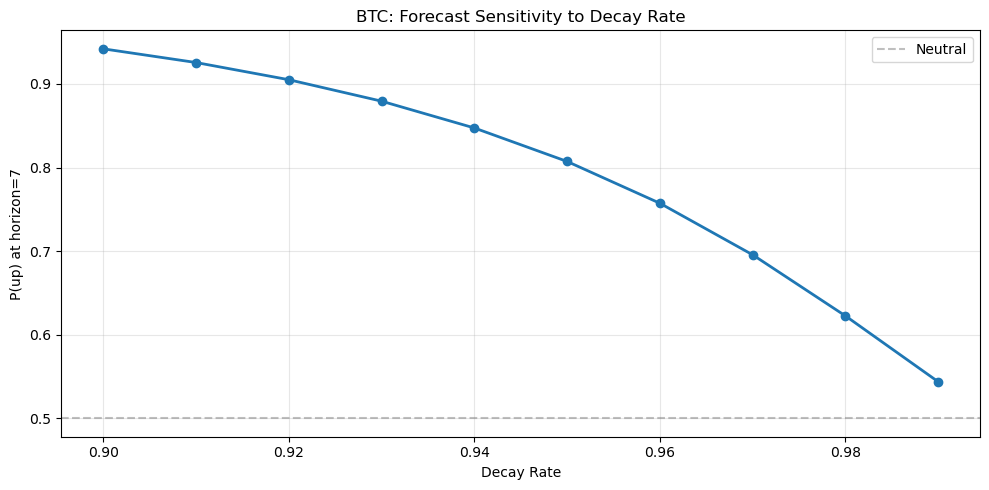

In [12]:
decay_rates = np.linspace(0.90, 0.99, 10)
p_up_values = []

for decay in decay_rates:
    P_temp = estimate_transition_matrix(regimes, decay_rate=decay)
    f_temp = compute_markov_forecast(P_temp, current_regime, HORIZON)
    up_temp = compute_regime_up_rates(regimes, returns, HORIZON, decay)
    combined = sum(f_temp[s] * up_temp[s] for s in ['bull', 'bear', 'sideways'])
    p_up_values.append(combined)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(decay_rates, p_up_values, marker='o', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Neutral')
ax.set_xlabel('Decay Rate')
ax.set_ylabel(f'P(up) at horizon={HORIZON}')
ax.set_title(f'{TICKER}: Forecast Sensitivity to Decay Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()